<a href="https://colab.research.google.com/github/KauaNasci/Churn-bank/blob/main/Churn_banc%C3%A1rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, accuracy_score, balanced_accuracy_score


In [ ]:
# 1. CARREGAMENTO E LIMPEZA DOS DADOS

df = pd.read_csv('/content/Customer-Churn-Records.csv')
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 2. Transformação de variáveis categóricas em numéricas

le = LabelEncoder()
for col in ['Gender', 'Geography', 'Card Type']:
    df_clean[col] = le.fit_transform(df_clean[col])

In [ ]:
# 3. DEFINIÇÃO DE X E Y (O coração do modelo realista)

X = df_clean.drop(['Exited', 'Complain', 'Satisfaction Score', 'Point Earned'], axis=1)
y = df_clean['Exited']

In [ ]:
# 4. DIVISÃO EM TREINO E TESTE

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# 5. TREINAMENTO DO MODELO

modelo_final = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
modelo_final.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
# 6. AVALIAÇÃO DO MODELO

previsoes_finais = modelo_final.predict(X_test)

# Cálculo das métricas

acc = accuracy_score(y_test, previsoes_finais)
acc_bal = balanced_accuracy_score(y_test, previsoes_finais)

print("--- RELATÓRIO DE CLASSIFICAÇÃO PROFISSIONAL ---")
print(classification_report(y_test, previsoes_finais))

print("-" * 50)
print(f"Acurácia Geral (Métrica Padrão): {acc:.2%}")
print(f"Acurácia Balanceada (Métrica Realista): {acc_bal:.2%}")
print("-" * 50)

--- RELATÓRIO DE CLASSIFICAÇÃO PROFISSIONAL ---
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1592
           1       0.79      0.45      0.57       408

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000

--------------------------------------------------
Acurácia Geral (Métrica Padrão): 86.30%
Acurácia Balanceada (Métrica Realista): 70.98%
--------------------------------------------------


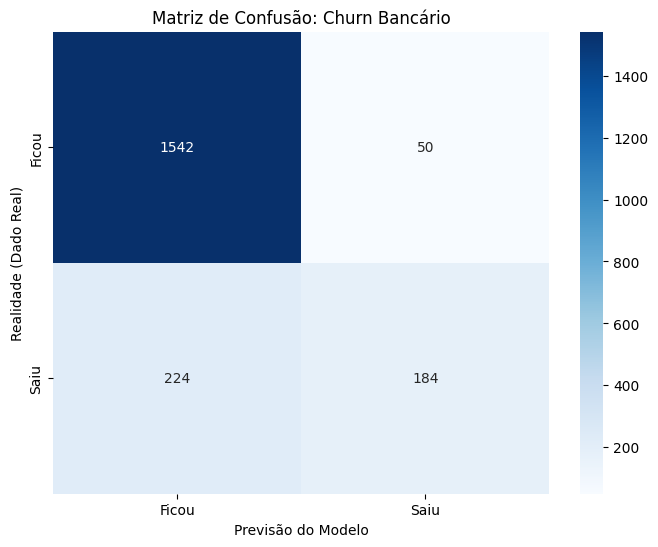

In [ ]:
# 7. MATRIZ DE CONFUSÃO

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, previsoes_finais)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ficou', 'Saiu'], yticklabels=['Ficou', 'Saiu'])
plt.xlabel('Previsão do Modelo')
plt.ylabel('Realidade (Dado Real)')
plt.title('Matriz de Confusão: Churn Bancário')
plt.show()


/tmp/ipykernel_4189/881235637.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=importancias, palette='magma')


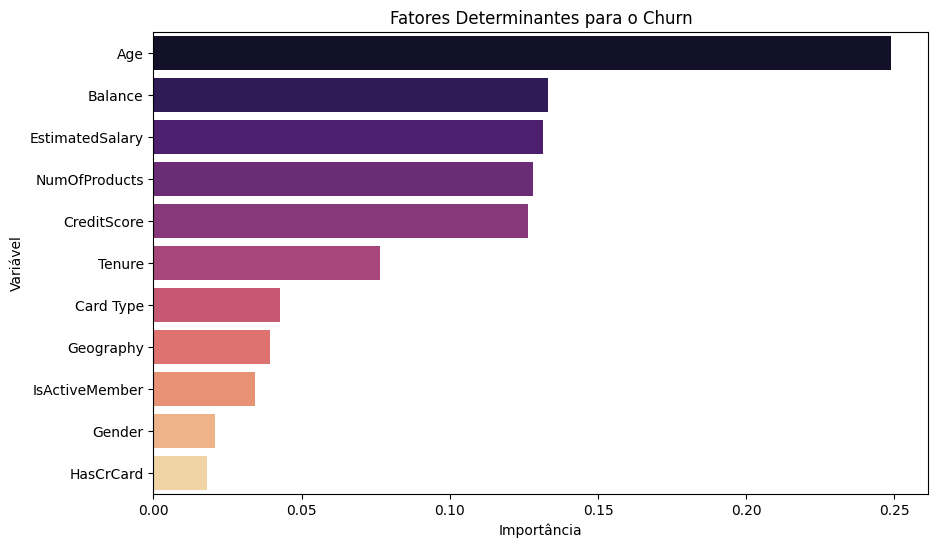

In [ ]:
# 8. IMPORTÂNCIA DAS VARIÁVEIS

importancias = pd.DataFrame({'Variável': X.columns, 'Importância': modelo_final.feature_importances_})
importancias = importancias.sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=importancias, hue='Variável', palette='magma', legend=False)
plt.title('Fatores Determinantes para o Churn')
plt.show()


In [ ]:
# 9. EXPORTAÇÃO

joblib.dump(modelo_final, 'modelo_churn_bancario.pkl')
print("Modelo salvo com sucesso 'modelo_churn_bancario.pkl'")

Modelo salvo com sucesso 'modelo_churn_bancario.pkl'


In [ ]:
df_clean.to_csv('churn_limpo_para_bi.csv', index=False)